# ESPM Course 2025
## Eight Notebook
Linear diffusion equation in two dimension using an explicit finite difference scheme to impose a bonudary condition (base level) in the interior of the domain, i.e., a sinusoidal, meandering river with a tilt

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import numba

Note that the domain is elongated imn the $x$-direction this time

We also define a boolean array, mask, of dimension (ny,nx) that contains the geometry of the base level (False values)

Npte also the large number of time steps to ensure stability as we are using an explicit formulation; we find, however, that performing the computation until tau/10 is sufficient to get close to steady-state

In [2]:
xl = 2000
yl = 1000
nx = 201
ny = 101
x,y = np.meshgrid(np.linspace(0, xl, nx), np.linspace(0, yl, ny))
dx = xl/(nx -1)
dy = yl/(ny -1)
Kd = 1e-2
taux = xl**2/Kd
tauy = yl**2/Kd
tau = np.amax([taux, tauy])
nstep = 20000
dt = tau/10/nstep
U = 1e-4

mask = np.ones((ny, nx), dtype=bool)

# a sinuosidal river kept to base level
xsin = np.linspace(0,nx-1,nx).astype(int)
ysin = (np.sin(2*np.pi*xsin/nx*2)*ny/3 + ny/2).astype(int)
mask[ysin, xsin] = False
#mask[ysin+1, xsin] = False

print('Courant:',dt*Kd/dy**2)

Courant: 0.2


We now proceed with a general form of the finite difference explicit scheme using a roll operation to find the derivative estimates and constrain the computations (uplift and diffusion) to be applied only where the mask is true

In [3]:
h = x/xl*100

for step in range(nstep):
    h[mask] = h[mask] + U*dt
    h = np.where(mask,
                  (h
                   + (Kd*dt/dx**2)*(np.roll(h, -1, axis=1) - 2*h + np.roll(h, 1, axis=1))
                   + (Kd*dt/dy**2)*(np.roll(h, -1, axis=0) - 2*h + np.roll(h, 1, axis=0))),
                  h)


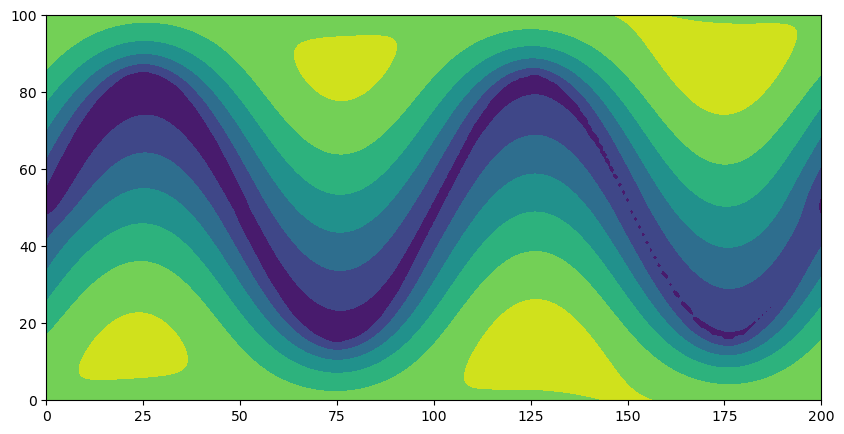

In [4]:
fig,ax = plt.subplots(figsize=(10,5))
ax.contourf(h)


We can use the same code to produce a smiley face

In [5]:
xl = 1000
yl = 1500
nx = 101
ny = 151
x,y = np.meshgrid(np.linspace(0, xl, nx), np.linspace(0, yl, ny))
dx = xl/(nx -1)
dy = yl/(ny -1)
Kd = 1e-2
taux = xl**2/Kd
tauy = yl**2/Kd
tau = np.amax([taux, tauy])
nstep = 20000
dt = tau/10/nstep
U = 1e-4

# smiley face mask : 2 eyes, a face and a smile

mask = np.ones((ny, nx), dtype=bool)

# eye 1
xc1 = 3*nx/8
yc1 = 2*ny/3
rax1 = nx/20
ray1 = nx/20
# eye 2
xc2 = 5*nx/8
yc2 = 2*ny/3
rax2 = nx/20
ray2 = nx/20
# face
xc3 = nx/2
yc3 = ny/2
rax3 = 2*nx/5
ray3 = ny/2
# smile
xc4 = nx/2
yc4 = 2*ny/5
rax4 = nx/5
ray4 = ny/6

for angle in np.linspace(0, 2*np.pi, 4*(nx+ny)):
    mask[(yc1+ray1*np.sin(angle)).astype(int), (xc1+rax1*np.cos(angle)).astype(int), ] = False
    mask[(yc2+ray2*np.sin(angle)).astype(int), (xc2+rax2*np.cos(angle)).astype(int), ] = False
    mask[(yc3+ray3*np.sin(angle)).astype(int), (xc3+rax3*np.cos(angle)).astype(int), ] = False
for angle in np.linspace(np.pi, 2*np.pi, 2*(nx+ny)):
    mask[(yc4+ray4*np.sin(angle)).astype(int), (xc4+rax4*np.cos(angle)).astype(int), ] = False


In [6]:
h = np.zeros((ny,nx))

for step in range(nstep):
    h[mask] = h[mask] + U*dt
    h = np.where(mask,
                  (h
                   + (Kd*dt/dx**2)*(np.roll(h, -1, axis=1) - 2*h + np.roll(h, 1, axis=1))
                   + (Kd*dt/dy**2)*(np.roll(h, -1, axis=0) - 2*h + np.roll(h, 1, axis=0))),
                  h)


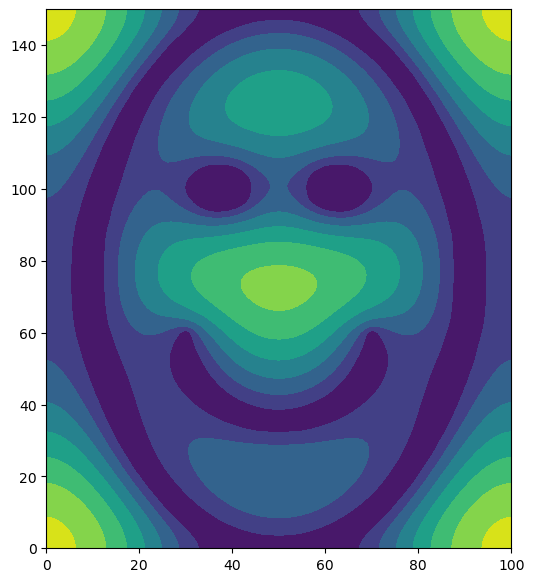

In [7]:
fig,ax = plt.subplots(figsize=(6,7))
ax.contourf(h)
